In [1]:
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import os
import sys
import logging

# Saving plots with editable text
plt.rcParams['pdf.fonttype'] = 42  # TrueType fonts (editable text)

In [2]:
# load file path from ocean
adata_infile_fiber = '/ocean/projects/cis240075p/asachan/datasets/TA_muscle/public_datasets/SKM_multimodal_ageing/objects/myofiber_type1.h5ad'
out_tmp = '/ocean/projects/cis240075p/asachan/datasets/TA_muscle/public_datasets/SKM_multimodal_ageing/objects/tmp'

In [3]:
from os.path import basename
import stream as st
adata = st.read(file_name=adata_infile_fiber, workdir=out_tmp)

/ocean/projects/cis240075p/asachan/.conda/envs/env_stream/lib/python3.7/site-packages/rpy2/robjects/pandas2ri.py:17: FutureWarning: pandas.core.index is deprecated and will be removed in a future version.  The public classes are available in the top-level namespace.
  from pandas.core.index import Index as PandasIndex


Saving results in: /ocean/projects/cis240075p/asachan/datasets/TA_muscle/public_datasets/SKM_multimodal_ageing/objects/tmp


In [5]:
# convert to dense
adata.X = adata.X.toarray()
adata.X.shape
adata.X.mean()
adata.X.min()
adata.X.max()


4.508642839947129

In [6]:
st.cal_qc(adata,assay='rna')

In [7]:
st.filter_cells(adata,min_n_features= 200)
st.filter_features(adata,min_n_cells = 10)

filter cells based on min_n_features
after filtering out low-quality cells: 
81981 cells, 48355 genes
Filter genes based on min_n_cells
After filtering out low-expressed genes: 
81981 cells, 36079 genes


In [8]:
###Normalize gene expression based on library size  
st.normalize(adata,method='lib_size')
###Logarithmize gene expression 
st.log_transform(adata)
###Remove mitochondrial genes 
st.remove_mt_genes(adata)

remove mitochondrial genes:
['MT-RNR1', 'MT-RNR2', 'MT-ND1', 'MT-ND2', 'MT-CO1', 'MT-CO2', 'MT-ATP8', 'MT-ATP6', 'MT-CO3', 'MT-ND3', 'MT-ND4L', 'MT-ND4', 'MT-ND5', 'MT-ND6', 'MT-CYB', 'MT-TF', 'MT-TV', 'MT-TL1', 'MT-TM', 'MT-TA', 'MT-TP', 'MT-TN', 'MT-TQ']


In [9]:
import numpy as np
import scipy.sparse as sp

X = adata.X
if sp.issparse(X):
    data = X.data
    data[np.isnan(data)] = 0
    X.eliminate_zeros()
else:
    np.nan_to_num(X, copy=False)  # in-place: NaN->0, inf->large finite

In [10]:
n_nans = np.isnan(X.data).sum() if sp.issparse(X) else np.isnan(X).sum()
display(n_nans)
display(adata.X.size)

0

2955906936

In [11]:
adata.obs['Annotation']

AGGATCTGCT_AACAGCATAG_1_1_1_1_1_1    Type I
TGATCGAGGT_AACGAGGTCC_1_1_1_1_1_1    Type I
TTATTGGACC_AACGAGTATT_1_1_1_1_1_1    Type I
GAGAGTCCGA_AAGATTAACC_1_1_1_1_1_1    Type I
CACGGATCGA_AAGTAAGCGT_1_1_1_1_1_1    Type I
                                      ...  
CELL3722_N1_2_2_11_1                 Type I
CELL2390_N1_2_2_11_1                 Type I
CELL4101_N1_2_2_11_1                 Type I
CELL3114_N1_2_2_11_1                 Type I
CELL4555_N1_2_2_11_1                 Type I
Name: Annotation, Length: 81981, dtype: category
Categories (5, object): ['Type I', 'DCLK1+ (I)', 'ID1+ (I)', 'SAA2+ (I)', 'TNNT2+ (I)']

### Stream fit elastic graph traj
#### pseudotime ordering already present in the dataset

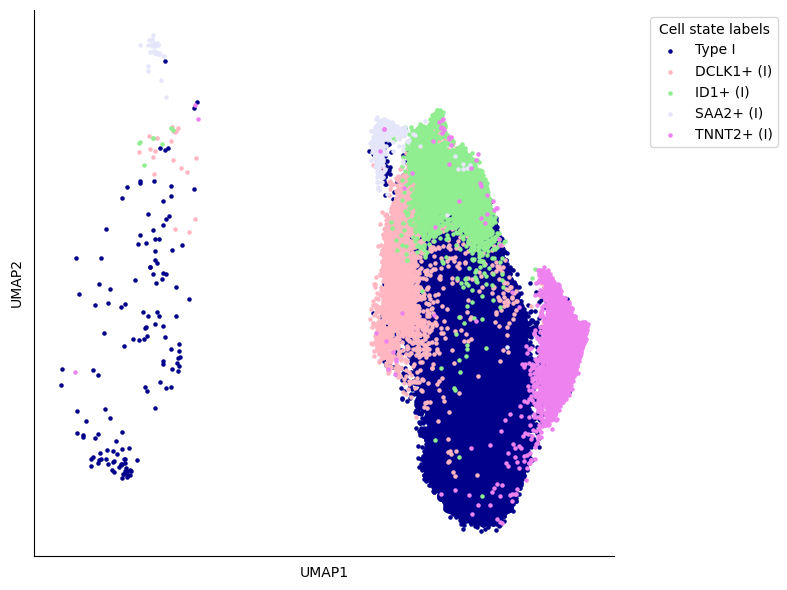

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Extract UMAP coordinates from the 'X_dr'/'X_mlle' or umap slot 
umap_coords = adata.obsm['X_umap']

# Extract the labels for coloring
labels = adata.obs['Annotation']

# get colors for 'Type I', 'DCLK1+ (I)', 'ID1+ (I)', 'SAA2+ (I)', 'TNNT2+ (I)'
colormap = {'Type I': 'darkblue', 'DCLK1+ (I)': 'lightpink', 'ID1+ (I)': 'lightgreen', 'SAA2+ (I)': 'lavender', 'TNNT2+ (I)': 'violet'}

# Get unique labels and their corresponding colors
unique_labels = labels.unique()
color_list = [colormap[label] for label in unique_labels]

# Plotting the UMAP with colors based on labels
plt.figure(figsize=(8, 6))

for label, color in zip (unique_labels, color_list):
    idx = labels == label
    plt.scatter(umap_coords[idx, 0], umap_coords[idx, 1], c=color, label=label, s=5)  # s=5 sets the marker size to 5 points
# Remove ticks
plt.xticks([])
plt.yticks([])
# Remove top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.title('')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend(title="Cell state labels", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
# plt.savefig('/ocean/projects/cis240075p/asachan/datasets/B_Cell/multiome_1st_donor_UPMC_aggr/stream_outs/figures/bifurcation_male.pdf', 
#             bbox_inches='tight',  # Ensures the legend isn't cut off
#             dpi=300,             # High resolution
#             format='pdf')        # Specify PDF format
#save the plot
#plt.savefig('/ocean/projects/cis240075p/asachan/datasets/B_Cell/T_cell/outs/stream_objs/tcell_traj_umap.pdf')
plt.show()

In [13]:
import os
os.environ.pop('R_LIBS_USER', None)  # Remove custom library path
os.environ.pop('R_LIBS', None)

'/ocean/projects/cis240075p/asachan/.conda/envs/env_stream/lib/R/library'

In [14]:
from rpy2.robjects import r
r('library(rlang)')

'rlang','tools','stats','graphics',...,'utils','datasets','methods','base'


In [15]:
adata.obsm['X_dr'] = adata.obsm['X_umap']

In [16]:
import os
os.environ["OMP_NUM_THREADS"] = "64"
from tempfile import TemporaryDirectory

# Parameters for STREAM (tune to your dataset)
ka1={'epg_alpha':0.05,'epg_mu':0.3,'epg_lambda':0.05,'epg_trimmingradius':2} # epg_mu needs to be higher for less plasticity; alpha controls branching
ka2={'epg_ext_mode':'QuantDists','epg_ext_par':1.}

# Trajectory inference
with TemporaryDirectory() as td:
	st.set_workdir(adata,td)
	st.seed_elastic_principal_graph(adata,n_clusters=2)
	st.elastic_principal_graph(adata,**ka1)
	st.extend_elastic_principal_graph(adata,**ka2)
	

Saving results in: /tmp/tmp4pdkn5_m
Seeding initial elastic principal graph...
Clustering...
K-Means clustering ...
The number of initial nodes is 2
Calculatng minimum spanning tree...
Number of initial branches: 1
Learning elastic principal graph...
[1]
 "Constructing tree 1 of 1 / Subset 1 of 1"


[1]
 "Computing EPG with 50 nodes on 81981 points and 2 dimensions"


[1]
 "Using a single core"


Nodes = 
2
 
3
 
4
 
5
 
6
 
7
 
8
 
9
 
10
 
11
 
12
 
13
 
14
 
15
 
16
 
17
 
18
 
19
 
20
 
21
 
22
 
23
 
24
 
25
 
26
 
27
 
28
 
29
 
30
 
31
 
32
 
33
 
34
 
35
 
36
 
37
 
38
 
39
 
40
 
41
 
42
 
43
 
44
 
45
 
46
 
47
 
48
 
49
 


BARCODE	ENERGY	NNODES	NEDGES	NRIBS	NSTARS	NRAYS	NRAYS2	MSE	MSEP	FVE	FVEP	UE	UR	URN	URN2	URSD

2||50
	
0.6689
	
50
	
49
	
44
	
2
	
0
	
0
	
0.4171
	
Inf
	
0.9363
	
-Inf
	
0.24
	
0.01182
	
0.5912
	
29.56
	
0




/ocean/projects/cis240075p/asachan/.conda/envs/env_stream/lib/python3.7/site-packages/rpy2/rinterface/__init__.py:146: RRuntimeWarning: Registered S3 methods overwritten by 'ggplot2':
  method         from 
  [.quosures     rlang
  c.quosures     rlang
  print.quosures rlang

  warnings.warn(x, RRuntimeWarning)


219.592 sec elapsed

[[1]]



Number of branches after learning elastic principal graph: 5
Extending leaves with additional nodes ...
Number of branches after extending leaves: 5


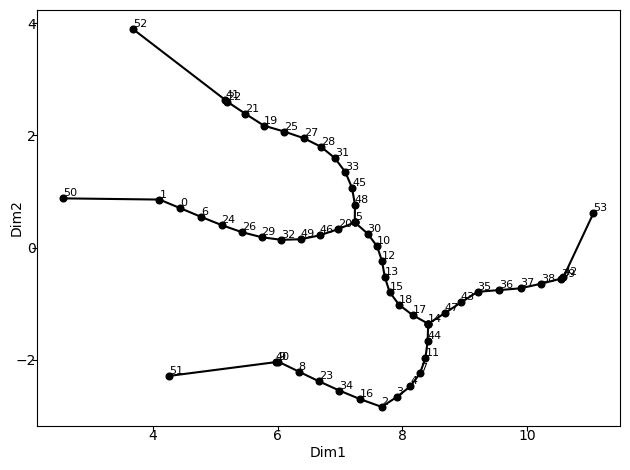

In [17]:
st.plot_branches(adata,show_text=True, n_components=2)

In [18]:
import pandas as pd

# ── Annotation ────────────────────────────────────────────────────────────────
adata.obs['Annotation'] = pd.Categorical(
    adata.obs['Annotation'],
    categories=['Type I', 'DCLK1+ (I)', 'ID1+ (I)', 'SAA2+ (I)', 'TNNT2+ (I)'],
    ordered=True
)

colormap_annotation = {
    'Type I':      '#4C72B0',   # steel blue
    'DCLK1+ (I)': '#DD8452',   # warm orange
    'ID1+ (I)':   '#55A868',   # muted green
    'SAA2+ (I)':  '#C44E52',   # muted red
    'TNNT2+ (I)': '#8172B2',   # purple
}

# ── Age population ────────────────────────────────────────────────────────────
adata.obs['age_pop'] = pd.Categorical(
    adata.obs['age_pop'],
    categories=['young_pop', 'old_pop'],
    ordered=True
)

colormap_age_pop = {
    'young_pop': '#74C476',   # fresh green
    'old_pop':   '#6A3D9A',   # deep purple
}

# ── Samples (22 unique colors) ────────────────────────────────────────────────
# Grouped loosely by prefix (OM=oranges/reds, YM=greens/teals, P=blues/purples)
# so biological groupings are visually hinted at while each sample stays distinct.
adata.obs['sample'] = pd.Categorical(
    adata.obs['sample'],
    categories=['OM9','YM3','OM6','OM5','OM8','YM1','P5','OM7','P21','P3',
                'YM2','P13','OM3','P23','P27','OM2','YM4','P29','P17','OM1','OM4','P26'],
    ordered=True
)

colormap_sample = {
    # OM samples — warm orange/red spectrum (9 samples)
    'OM1': '#FFA500',   # orange
    'OM2': '#FF7F00',   # dark orange
    'OM3': '#E64B00',   # burnt orange
    'OM4': '#CC2900',   # deep red-orange
    'OM5': '#FF4D4D',   # coral red
    'OM6': '#FF9999',   # light coral
    'OM7': '#C0392B',   # crimson
    'OM8': '#F1948A',   # dusty rose
    'OM9': '#FFCBA4',   # peach

    # YM samples — green/teal spectrum (4 samples)
    'YM1': '#2ECC71',   # emerald
    'YM2': '#1ABC9C',   # teal
    'YM3': '#27AE60',   # forest green
    'YM4': '#76D7C4',   # mint

    # P samples — blue/purple/violet spectrum (9 samples)
    'P3':  '#3498DB',   # bright blue
    'P5':  '#2980B9',   # medium blue
    'P13': '#1A5276',   # navy
    'P17': '#7D3C98',   # purple
    'P21': '#9B59B6',   # medium purple
    'P23': '#D2B4DE',   # lavender
    'P26': '#5DADE2',   # sky blue
    'P27': '#A569BD',   # violet
    'P29': '#4A235A',   # deep plum
}

# ── Map colors onto adata.obs ─────────────────────────────────────────────────
adata.obs['Annotation_colors'] = adata.obs['Annotation'].map(colormap_annotation)
adata.obs['age_pop_colors']    = adata.obs['age_pop'].map(colormap_age_pop)
adata.obs['sample_colors']     = adata.obs['sample'].map(colormap_sample)

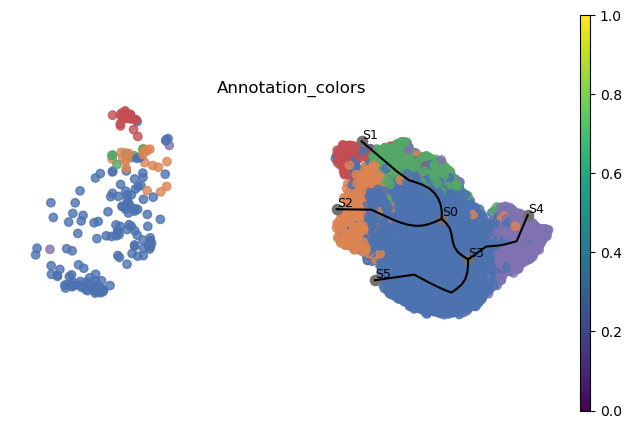

In [19]:
import matplotlib.pyplot as plt

st.plot_dimension_reduction(adata,show_graph=True,show_text=True,color=['Annotation_colors'])
ax=plt.gca()
ax.set_aspect(1)
ax.axis('off');


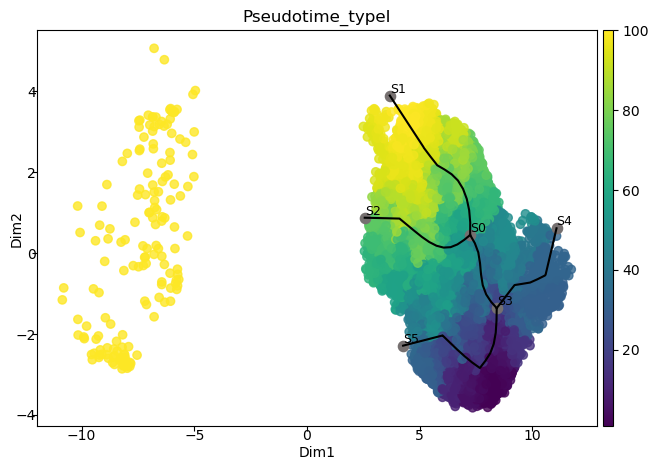

In [20]:
st.plot_dimension_reduction(adata,show_graph=True,show_text=True,color=['Pseudotime_typeI'])

In [22]:
# Remove specific branches by specifying nodes to keep
st.prune_elastic_principal_graph(adata)

Collasping small branches ...
[1]
 "Constructing tree 1 of 1 / Subset 1 of 1"


[1]
 "Computing EPG with 50 nodes on 81981 points and 2 dimensions"


[1]
 "Using a single core"


0.185 sec elapsed

Number of branches after pruning ElPiGraph: 5


In [32]:
adata.obs['branch_id'].value_counts()

(40, 14)    24455
(1, 5)      19434
(41, 5)     17723
(14, 5)     11716
(42, 14)     8653
Name: branch_id, dtype: int64

In [33]:
import networkx as nx
import numpy as np


def _label_to_key(flat_tree, label):
    """Return the integer node key for a given 'S0'-style label."""
    for k, d in flat_tree.nodes(data=True):
        if d.get('label') == label:
            return k
    raise ValueError(f"Node with label '{label}' not found in flat_tree.")


def remove_branch_node(adata, label, merge_strategy='shortest'):
    """
    Remove a node from adata.uns['flat_tree'] and adata.uns['epg'] by
    contracting it into its neighbours.

    Parameters
    ----------
    adata : AnnData
        Processed STREAM AnnData object (post elastic_principal_graph).
    label : str
        Label of the node to remove, e.g. 'S0' or 'S4'.
    merge_strategy : str
        How to reconnect neighbours when the node has degree > 2.
        'shortest' : keep only the pair of neighbours with the shortest
                     combined edge length (drops the extra branch).
        'all'      : connect every pair of remaining neighbours
                     (may create a clique — use with care).
    """
    ft = adata.uns['flat_tree']
    epg = adata.uns['epg']

    # ── flat_tree surgery ────────────────────────────────────────────────────
    key = _label_to_key(ft, label)
    nbrs = list(ft.neighbors(key))
    deg = len(nbrs)

    if deg == 0:
        # isolated node — just remove it
        ft.remove_node(key)

    elif deg == 1:
        # leaf — just remove it (prunes the terminal branch)
        ft.remove_node(key)

    elif deg == 2:
        # pass-through node: bridge the two neighbours directly
        n1, n2 = nbrs
        new_len = (ft.edges[key, n1].get('len', 1.0) +
                   ft.edges[key, n2].get('len', 1.0))
        ft.remove_node(key)               # also removes its edges
        ft.add_edge(n1, n2, len=new_len)

    else:
        # true branch point (degree ≥ 3) ─────────────────────────────────────
        edge_lens = {n: ft.edges[key, n].get('len', 1.0) for n in nbrs}
        ft.remove_node(key)               # removes all incident edges

        if merge_strategy == 'all':
            # reconnect every pair of former neighbours
            for i, a in enumerate(nbrs):
                for b in nbrs[i+1:]:
                    new_len = edge_lens[a] + edge_lens[b]
                    if not ft.has_edge(a, b):
                        ft.add_edge(a, b, len=new_len)

        elif merge_strategy == 'shortest':
            # keep only the two neighbours with smallest edge lengths
            # (effectively drops the longest/extra branch stub)
            sorted_nbrs = sorted(nbrs, key=lambda n: edge_lens[n])
            n1, n2 = sorted_nbrs[0], sorted_nbrs[1]
            ft.add_edge(n1, n2, len=edge_lens[n1] + edge_lens[n2])
            # nodes of dropped branches stay in the graph but become
            # disconnected components — remove them recursively if desired
            for orphan in sorted_nbrs[2:]:
                component = nx.node_connected_component(ft, orphan)
                ft.remove_nodes_from(component)

        else:
            raise ValueError(f"Unknown merge_strategy: '{merge_strategy}'")

    # ── epg surgery (optional but keeps both graphs consistent) ──────────────
    # The epg uses raw integer keys; find the one closest to the flat_tree
    # node position (flat_tree node positions are averages of epg positions).
    if key in epg.nodes:
        # simple case: key exists directly in epg
        epg_nbrs = list(epg.neighbors(key))
        if len(epg_nbrs) == 2:
            n1, n2 = epg_nbrs
            epg.remove_node(key)
            epg.add_edge(n1, n2)
        else:
            epg.remove_node(key)

    print(f"Node '{label}' (key={key}) removed. "
          f"flat_tree now has {ft.number_of_nodes()} nodes, "
          f"{ft.number_of_edges()} edges.")


def remove_branch_nodes(adata, labels, merge_strategy='shortest'):
    """Remove multiple nodes by label. Order matters for branch points."""
    for lbl in labels:
        remove_branch_node(adata, lbl, merge_strategy=merge_strategy)


# ── relabel remaining nodes sequentially (optional) ──────────────────────────
def relabel_flat_tree(adata):
    """
    Reassign 'S0', 'S1', ... labels sequentially to whatever nodes remain.
    Call this after all removals.
    """
    ft = adata.uns['flat_tree']
    for new_idx, node_key in enumerate(ft.nodes()):
        ft.nodes[node_key]['label'] = f'S{new_idx}'


# ─────────────────────────────────────────────────────────────────────────────
# Usage
# ─────────────────────────────────────────────────────────────────────────────
# After st.elastic_principal_graph(adata) but before st.calculate_pseudotime():

remove_branch_nodes(adata, labels=['S0', 'S4'], merge_strategy='shortest')

# Optional: tidy up the remaining labels so they're still S0, S1, ...
relabel_flat_tree(adata)

Node 'S0' (key=1) removed. flat_tree now has 5 nodes, 4 edges.
Node 'S4' (key=42) removed. flat_tree now has 4 nodes, 3 edges.


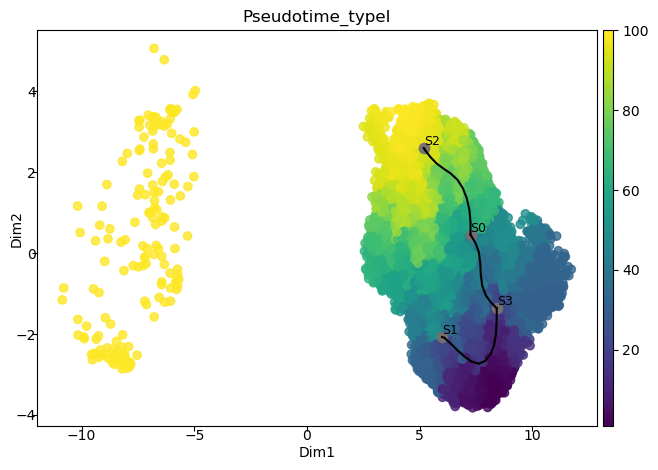

In [34]:
st.plot_dimension_reduction(adata,show_graph=True,show_text=True,color=['Pseudotime_typeI'])